## Библиотеки

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.multioutput import RegressorChain
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error

## Анализ данных температур

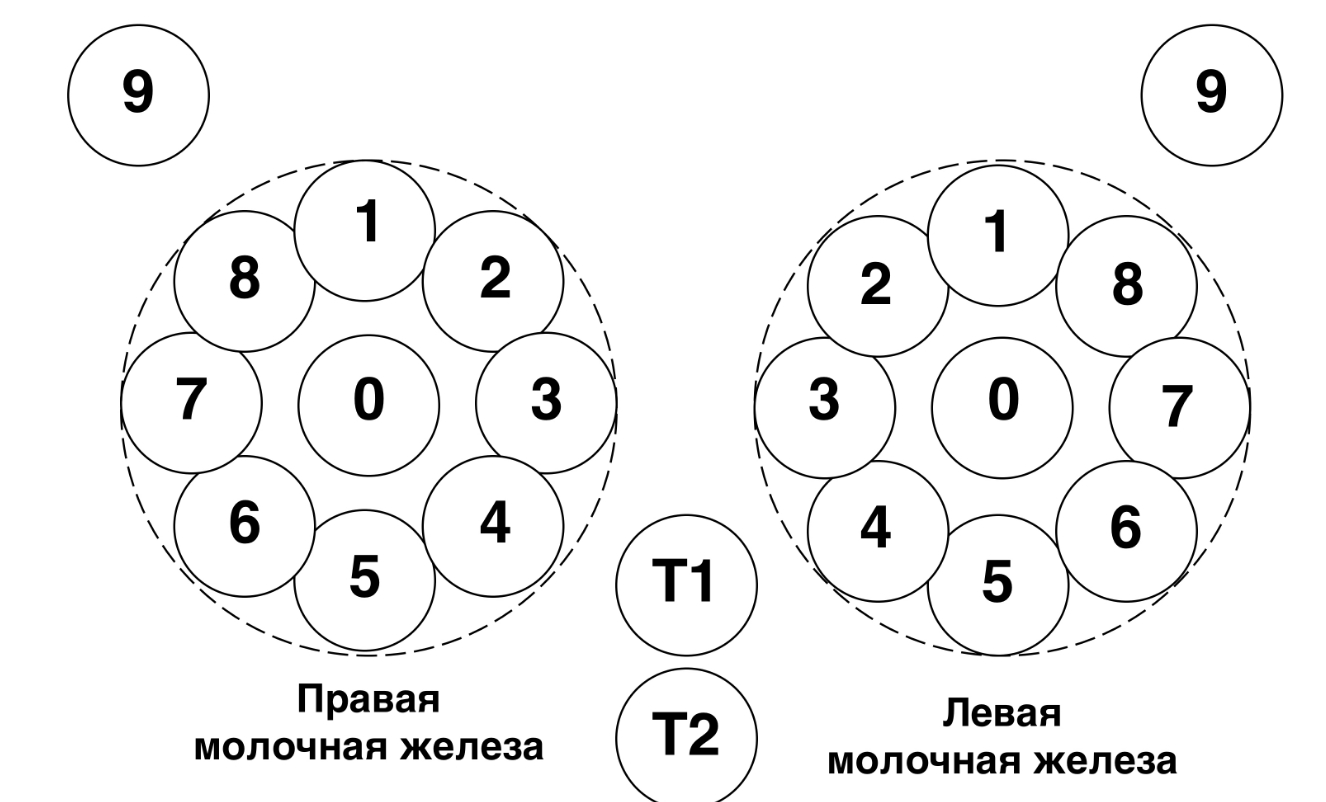

In [2]:
DATA_PATH = 'data/clarified_dataset.xlsx'

df = pd.read_excel(DATA_PATH)

In [3]:
HEALTH_STATUS_COLUMN = 'th_cls_breast'
BREAST_SIDE = 'breast'

right_temp_df = df[(df[HEALTH_STATUS_COLUMN] == 0) & (df[BREAST_SIDE] == 'r')]
left_temp_df = df[(df[HEALTH_STATUS_COLUMN] == 0) & (df[BREAST_SIDE] == 'l')]

x_cols = [f'ir_{i}' for i in range(0, 9)] # кожные температуры
y_cols = [f'mw_{i}' for i in range(0, 9)] # глубинные температуры
use_cols = x_cols + y_cols

temperature_df = df.loc[:, use_cols]
right_temp_df = right_temp_df.loc[:,  use_cols]
left_temp_df = left_temp_df.loc[:,  use_cols]

## Первичный анализ данных

Базовые параметры кожных температур:

In [4]:
temperature_df.loc[:, x_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ir_0,9162.0,33.050371,1.284449,25.2,32.4,33.2,33.9,36.9
ir_1,9162.0,33.221873,1.134680,27.8,32.6,33.4,34.0,36.2
ir_2,9162.0,33.243451,1.111068,26.7,32.6,33.4,34.0,36.0
ir_3,9162.0,33.160904,1.127247,27.7,32.5,33.3,33.9,36.1
ir_4,9162.0,33.042960,1.061980,27.6,32.4,33.2,33.8,36.2
ir_5,9162.0,32.828564,1.084798,27.2,32.2,32.9,33.6,36.0
ir_6,9162.0,32.476992,1.197549,27.3,31.7,32.6,33.3,35.7
ir_7,9162.0,32.591847,1.188675,27.1,31.9,32.7,33.4,35.7
ir_8,9162.0,32.953362,1.128646,27.9,32.3,33.1,33.7,36.2


Базовые параметры внутренних температур:

In [5]:
temperature_df.loc[:, y_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
mw_0,9162.0,34.907880,1.158463,28.0,34.3,35.1,35.7,37.4
mw_1,9162.0,35.046191,0.934144,29.2,34.6,35.2,35.7,37.5
mw_2,9162.0,35.155927,0.903005,29.1,34.7,35.3,35.8,37.3
mw_3,9162.0,35.070138,0.932060,30.2,34.6,35.2,35.7,37.3
mw_4,9162.0,34.943189,0.885102,30.3,34.5,35.1,35.6,37.4
mw_5,9162.0,34.794968,0.916795,30.1,34.3,34.9,35.4,37.3
mw_6,9162.0,34.578651,1.008297,29.4,34.0,34.7,35.3,37.0
mw_7,9162.0,34.688147,1.005841,29.4,34.1,34.8,35.4,37.3
mw_8,9162.0,34.926828,0.964052,29.5,34.4,35.1,35.6,37.4


Поиск пропусков и общая информация о датасете:

In [6]:
temperature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9162 entries, 0 to 9161
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ir_0    9162 non-null   float64
 1   ir_1    9162 non-null   float64
 2   ir_2    9162 non-null   float64
 3   ir_3    9162 non-null   float64
 4   ir_4    9162 non-null   float64
 5   ir_5    9162 non-null   float64
 6   ir_6    9162 non-null   float64
 7   ir_7    9162 non-null   float64
 8   ir_8    9162 non-null   float64
 9   mw_0    9162 non-null   float64
 10  mw_1    9162 non-null   float64
 11  mw_2    9162 non-null   float64
 12  mw_3    9162 non-null   float64
 13  mw_4    9162 non-null   float64
 14  mw_5    9162 non-null   float64
 15  mw_6    9162 non-null   float64
 16  mw_7    9162 non-null   float64
 17  mw_8    9162 non-null   float64
dtypes: float64(18)
memory usage: 1.3 MB


Поиск дубликатов:

In [7]:
temperature_df[temperature_df.duplicated()]

,ir_0,ir_1,ir_2,ir_3,ir_4,ir_5,ir_6,ir_7,ir_8,mw_0,mw_1,mw_2,mw_3,mw_4,mw_5,mw_6,mw_7,mw_8
754,32.9,33.2,33.4,34.7,33.5,33.4,32.9,33.0,32.8,35.2,34.7,35.4,35.8,35.5,35.3,35.0,34.9,34.6
1064,35.5,35.5,35.2,34.8,34.6,35.0,34.7,34.9,34.7,36.3,36.0,36.0,35.9,35.3,35.8,35.6,36.0,35.9
1476,31.4,31.8,32.3,33.0,33.0,31.5,28.8,29.8,31.0,33.3,33.3,34.7,34.9,35.0,34.0,31.2,31.7,32.6
1662,33.0,33.2,32.8,32.8,33.1,33.0,32.4,32.9,33.9,34.8,35.1,34.8,34.9,34.8,34.7,34.1,34.7,35.0
2962,33.8,34.4,32.7,33.7,34.0,34.1,32.6,33.3,33.4,35.6,36.5,35.1,35.5,35.9,35.6,35.1,35.4,35.4
3092,33.2,33.3,33.5,33.0,32.8,32.5,32.0,33.1,33.0,35.4,35.5,35.7,35.3,35.0,34.6,34.3,35.0,35.3
5220,32.7,33.5,33.8,33.7,34.2,34.0,33.3,32.2,33.8,34.9,35.2,35.7,35.6,36.0,35.6,34.8,34.4,35.2
6007,31.5,32.6,33.0,32.9,33.3,32.7,32.4,31.1,31.4,33.6,34.3,35.3,35.1,35.4,35.3,34.4,33.4,33.7
6208,32.5,32.8,32.4,33.2,33.4,33.3,32.5,32.1,33.5,34.3,34.4,34.3,34.6,35.2,34.6,34.1,34.3,35.1
6476,31.6,31.4,31.7,31.1,30.7,30.4,31.3,30.9,31.1,34.2,34.1,34.8,34.6,34.2,34.0,34.5,34.6,34.5


In [8]:
temperature_df.drop_duplicates(inplace=True)

<h3>Вывод 1</h3>

Используемый датасет чистый. То есть нету пропусков в данных и выбросов. Но было найдено 13 дубликатов, которые были удалены.

Построение корреляционной матрицы:

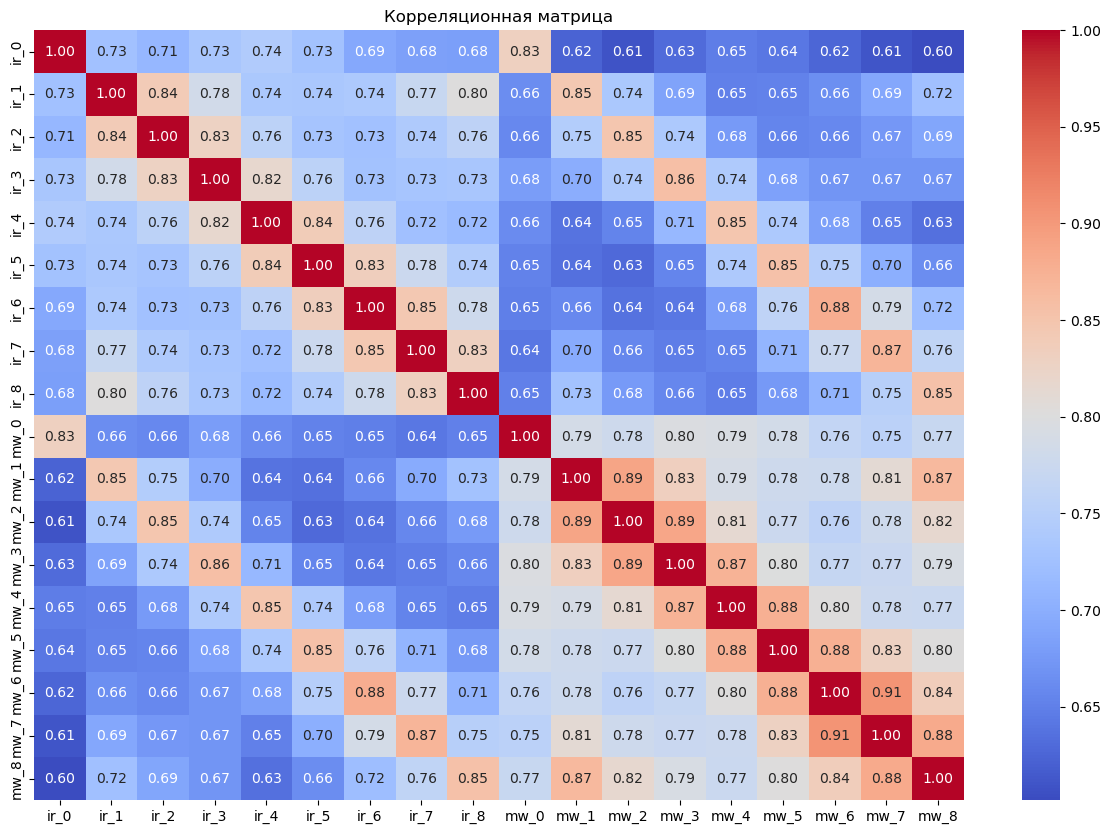

In [9]:
corr_matrix = temperature_df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

<h3>Вывод 2</h3>
Для кожных и внутренних температур максимальная корреляция наблюдается у соответствующих признаков, например, между ir_0 и mv_0 коффициент корреляции равен 0.8. <br>
<br>
Далее, корреляция наблюдается у соседних точек измерения, например, между ir_1, ir_3 и mv_2 корреляция 0.73. <br>
<br>
Также, корреляция наблюдается между соседними кожными температурами, например, у ir_4 с ir_3 и ir_5 корреляция составляет 0.83 и 0.84 соответственно.

Посмотрим на распределение целевых переменных:

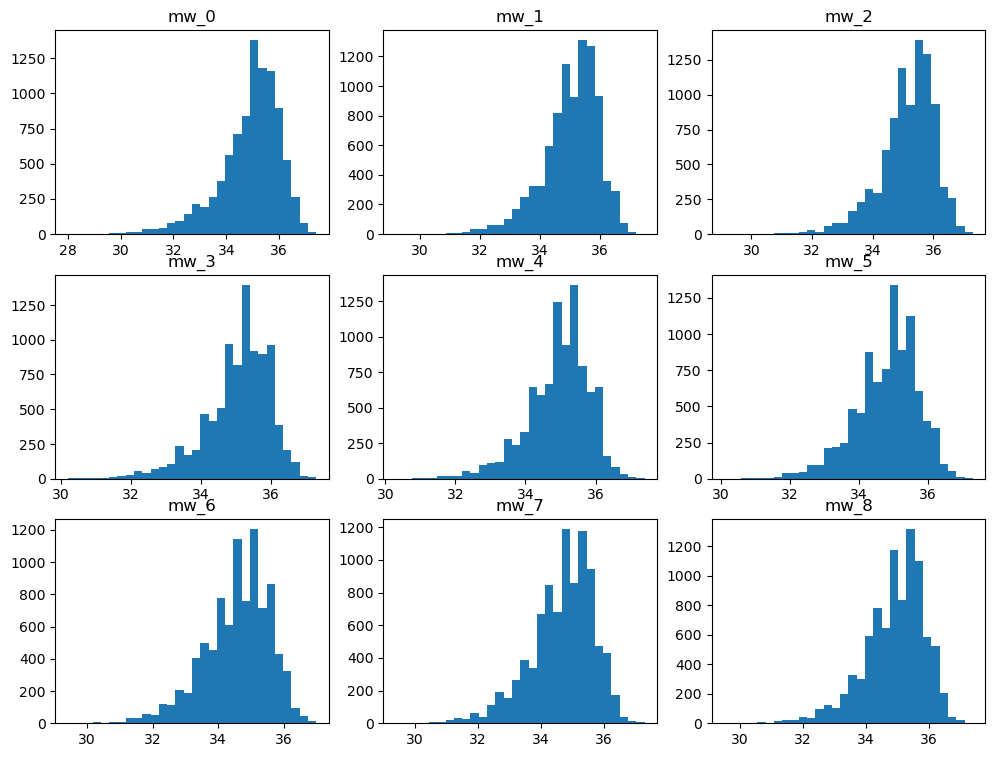

In [10]:
figure, axes = plt.subplots(ncols=3, nrows=3, figsize=(12, 9))
axes = axes.ravel()

for ax, target in zip(axes, y_cols):
    ax.hist(temperature_df[target], bins=30)
    ax.set_title(f'{target}')

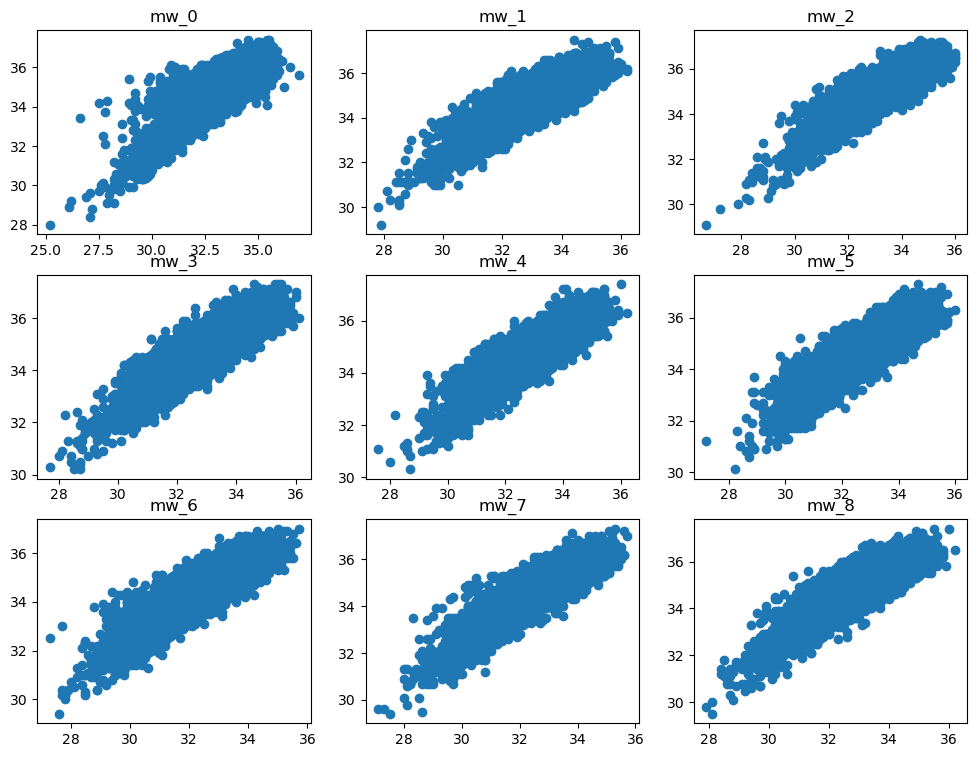

In [11]:
figure, axes = plt.subplots(ncols=3, nrows=3, figsize=(12, 9))
axes = axes.ravel()

for ax, y, x in zip(axes, y_cols, x_cols):
    ax.scatter(temperature_df[x], temperature_df[y])
    ax.set_title(f'{y}')

<h3>Вывод 3</h3>

Распределение непрерывной случайной величины напоминает нормальное распределение.

## Создание новых признаков

Чтобы снизить корреляцию между входными температурами, были добавлены следующие модификации: квадрат, куб, экспонента с отрицательным аргументом, синус, тангенс, логарифм по основанию 2, квадратный корень, а также среднее арифметическое и разница максимальной и минимальной кожных температур для каждой строки. <br>
<br>
При предварительном обучении регрессии LASSO было выяснено, что самыми информативными модификациями признаков являются: квадратичная функция, экспонента с отрицательным аргументом, синус, разница максимальной и минимальной кожных температур.

In [12]:
cols_funcs = {
    "pow_2": lambda x: np.pow(x, 2),
    'exp': lambda x: np.exp(-x),
    'sin': lambda x: np.sin(x),
}

rows_funcs = {
    "max-min": lambda x: x.max(axis=1) - x.min(axis=1),
}

generated_feature_x = []

for key, func in cols_funcs.items():
    for col in x_cols:
        name_new_col = f'{col}_{key}'
        temperature_df[name_new_col] = func(temperature_df[col])
        generated_feature_x.append(name_new_col)


for key, func in rows_funcs.items():
    temperature_df[key] = func(temperature_df[x_cols])
    generated_feature_x.append(key)

Корреляция только между сгенерированными признаками:

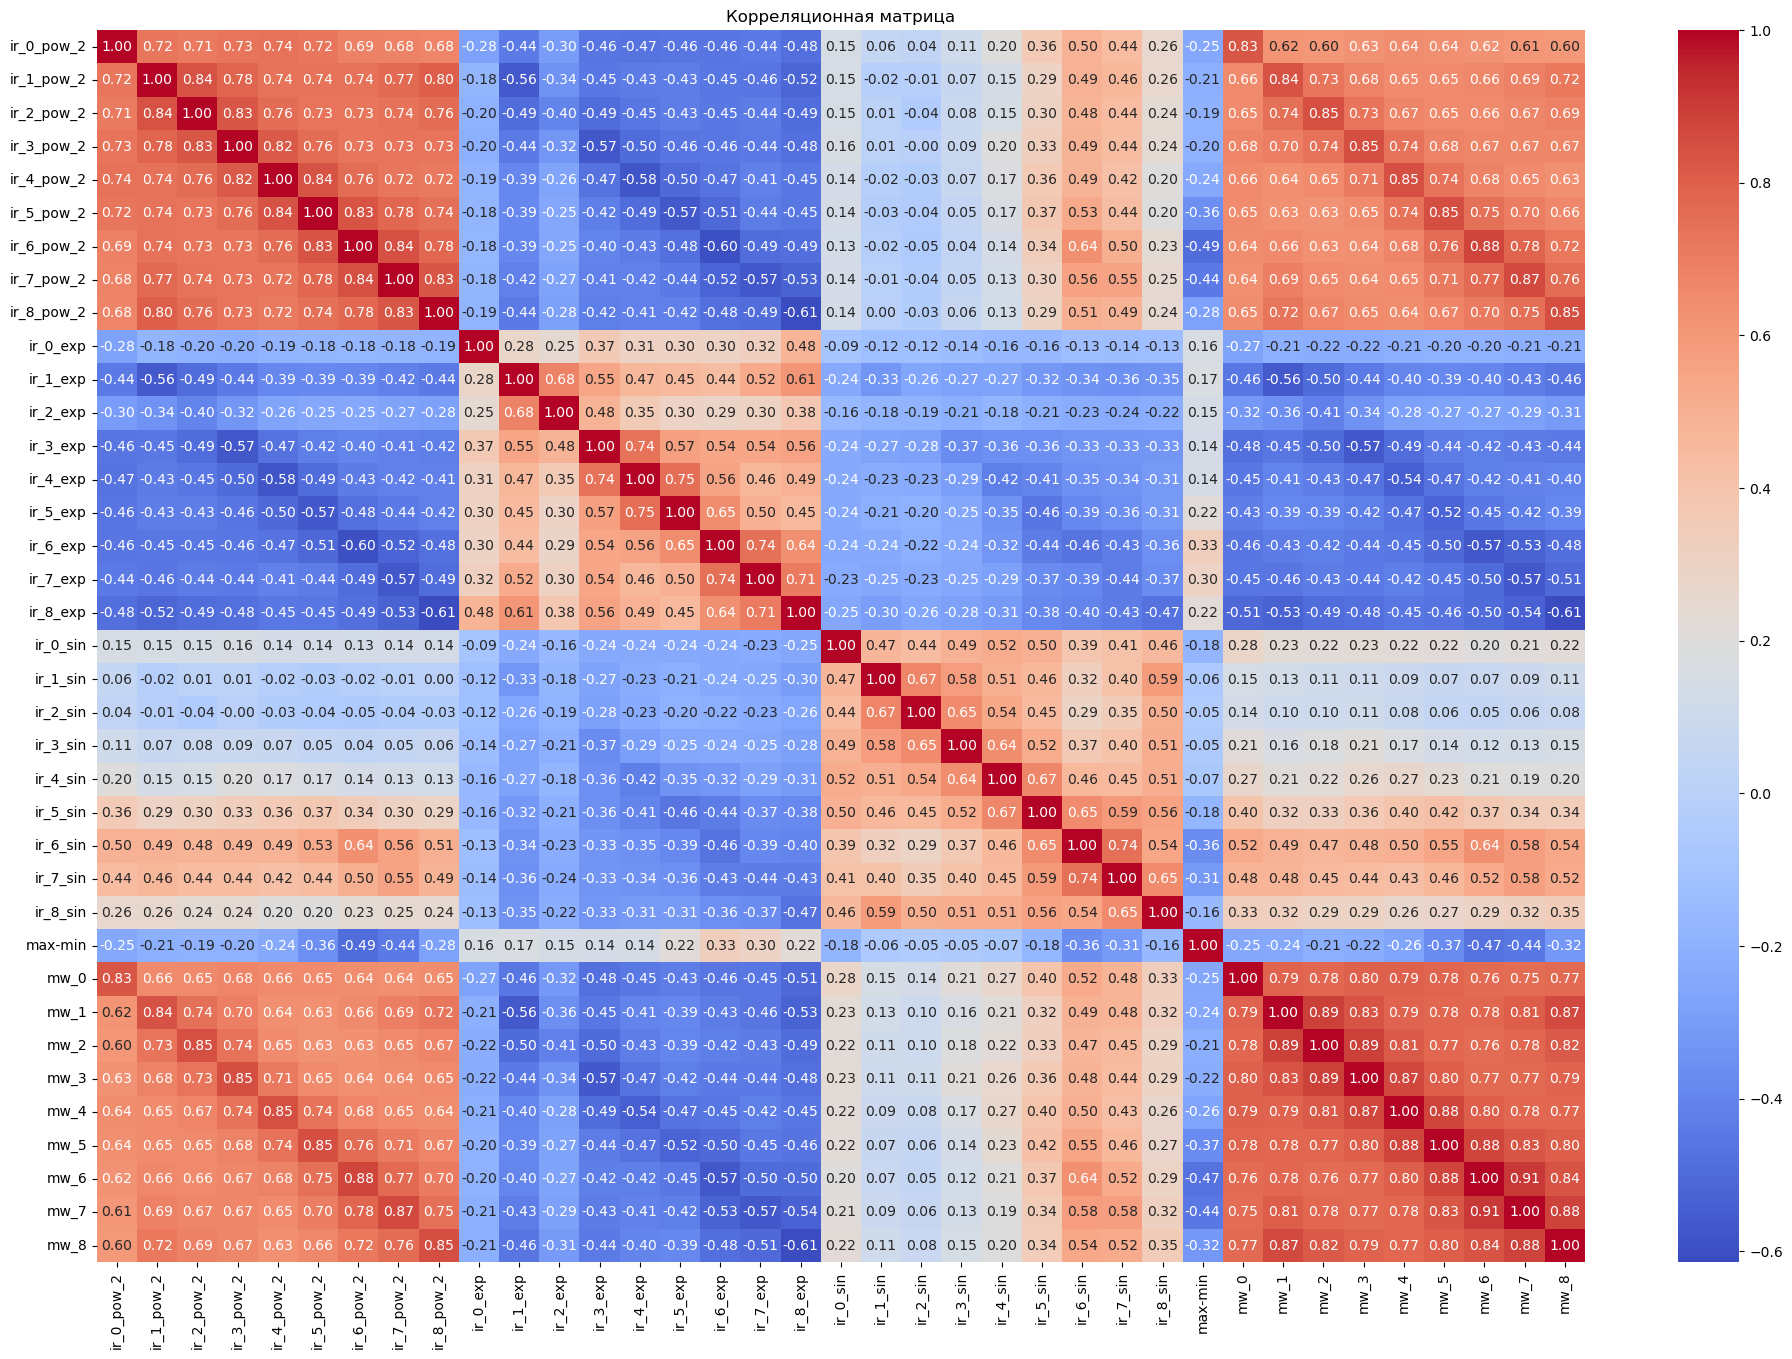

In [13]:
corr_matrix = temperature_df[generated_feature_x + y_cols].corr()

plt.figure(figsize=(24, 16))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляционная матрица')
plt.show()

## Применение алгоритмов линейной регрессии

In [14]:
new_and_old_xcols = x_cols + generated_feature_x

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    temperature_df[generated_feature_x], temperature_df[y_cols], test_size=0.2, random_state=42)

`Линейная регрессия с применением стандартизации данных:`

In [16]:
line_reg_pipline = make_pipeline(
    StandardScaler(),
    LinearRegression(n_jobs=-1)
)

line_reg_pipline.fit(X_train, y_train)

y_pred = line_reg_pipline.predict(X_test)

error_mae = mean_absolute_error(y_pred, y_test)

print(error_mae)

0.37322717675168526


`Полиномиальная регрессия:`

In [17]:
poly_features_pipline = make_pipeline(
    PolynomialFeatures(degree=2),
    StandardScaler(),
    LinearRegression(n_jobs=-1)
)

poly_features_pipline.fit(X_train, y_train)

pred = poly_features_pipline.predict(X_test)

print(mean_absolute_error(y_test, pred))

0.4447707915760406


`Lasso:`

С помощью GridsearchCV был найден наилучший параметр **alpha = 0.0001**. В качестве обучающих данных были использованны начальные температуры и сгенерированные признаки. Применялась стандартизация.

In [18]:
lasso_pipline = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.0001, max_iter=1000)
)

lasso_pipline.fit(X_train, y_train)

y_pred = lasso_pipline.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.37320262160887463


Redge

In [19]:
ridge_pipline = make_pipeline(
    StandardScaler(),
    Ridge(alpha=0.07)
)

ridge_pipline.fit(X_train, y_train)

y_pred = ridge_pipline.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.37322716907461523


`ElasticNet`

In [20]:
elastic_net_pipline = make_pipeline(
    StandardScaler(),
    ElasticNet(alpha=0.0001, l1_ratio=0.01)
)

elastic_net_pipline.fit(X_train, y_train)

y_pred = elastic_net_pipline.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.3732268740139053


`Модель цепочной линейной регрессии:`

In [21]:
model = LinearRegression()
chain = RegressorChain(model)

line_reg_chain_pipline = make_pipeline(
    StandardScaler(),
    chain
)

line_reg_chain_pipline.fit(X_train, y_train)

predicts = line_reg_chain_pipline.predict(X_test)

print(mean_absolute_error(y_test, predicts))

0.3732271767516851


## Дерево решений

In [22]:
model = DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, max_features=23)

model.fit(X_train, y_train)

predicts = model.predict(X_test)

print(mean_absolute_error(y_test, predicts))

0.43624532719890025


In [23]:
model_tree = DecisionTreeRegressor(criterion='absolute_error', max_depth=10, min_samples_leaf=50, max_features=23)

chain = RegressorChain(model_tree, order=[1, 2, 3, 4, 5, 6, 7, 8, 0])

chain.fit(X_train, y_train)

y_pred = chain.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.4261020036429874


`Случайный лес:`

In [24]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(criterion='absolute_error', max_depth=10, min_samples_split=2, min_samples_leaf=20, n_estimators=30)

forest_model.fit(X_train, y_train)

y_pred = forest_model.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.4159097348714831


## kNN

In [25]:
param_grid = {
    'kneighborsregressor__n_neighbors': range(1, 30),
    'kneighborsregressor__algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'kneighborsregressor__weights': ['uniform', 'distance'], 
    'kneighborsregressor__p': [1, 2]
}

knn_pipline = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor()
)

grid_search = GridSearchCV(knn_pipline, param_grid, cv=5, scoring='neg_mean_absolute_error', refit=True)

grid_search.fit(X_train, y_train)

y_pred = grid_search.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.3914157620901344


In [26]:
grid_search.best_params_

{'kneighborsregressor__algorithm': 'ball_tree',
 'kneighborsregressor__n_neighbors': 26,
 'kneighborsregressor__p': 2,
 'kneighborsregressor__weights': 'distance'}

In [27]:
grid_search.best_score_

np.float64(-0.4064669475368077)

## Стекинг дерева решений и kNN с референтным методом линейной регресии

In [28]:
from sklearn.ensemble import StackingRegressor

estimators = [
    ('svr', DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, max_features=23)),
    ('knn', make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=26, algorithm='ball_tree', weights='distance', p=2, n_jobs=-1)))
]

stacking_model = StackingRegressor(
    estimators=estimators, final_estimator=LinearRegression()
)

chained_model = RegressorChain(stacking_model, order='random', random_state=42)

chained_model.fit(X_train, y_train)

y_pred = chained_model.predict(X_test)

print(mean_absolute_error(y_test, y_pred))

0.39698710418568867
